In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))  # adds /home/patroklos/delphi.ai to the path

from delphi.grad import TruncatedMSE

import torch as ch
import matplotlib.pyplot as plt
%matplotlib notebook
import numpy as np
from sklearn.linear_model import LinearRegression

ch.set_printoptions(precision=4, sci_mode=False)

In [104]:
def trunc_mse(pred, targ, phi, noise_var, seed=69): 
    if seed is not None:
        ch.manual_seed(seed)
    pred.requires_grad = True
    loss = TruncatedMSE.apply(pred, targ, phi, noise_var)
    loss.backward()
    return loss, pred.grad

# One Dimensional Truncated Linear Regression

In [105]:
W = ch.ones(1)
print(f'groud truth W:\n {W}')

X = ch.rand(1000, 1)
print(f'ground truth num samples: {X.size(0)}')

Y = X @ W + ch.randn(X.size(0))

gt_lin_reg = LinearRegression(fit_intercept=False)
gt_lin_reg.fit(X, Y)

W_fit = gt_lin_reg.coef_

print(f'W fit:\n {W_fit}')

groud truth W:
 tensor([1.])
ground truth num samples: 1000
W fit:
 [0.98468685]


In [106]:
def phi(X): 
    return X > 0
#     return ch.ones_like(X)

trunc_indices = phi(Y).nonzero()
alpha = trunc_indices.size(0) / X.size(0)
print(f'alpha:\n {alpha:.3f}')

Y_trunc = Y[trunc_indices]
X_trunc = X[trunc_indices.flatten()]

trunc_lin_reg = LinearRegression(fit_intercept=False)
trunc_lin_reg.fit(X_trunc, Y_trunc)

print(f'trunc lin reg W:\n {trunc_lin_reg.coef_}')

alpha:
 0.683
trunc lin reg W:
 [[1.6116431]]


<IPython.core.display.Javascript object>


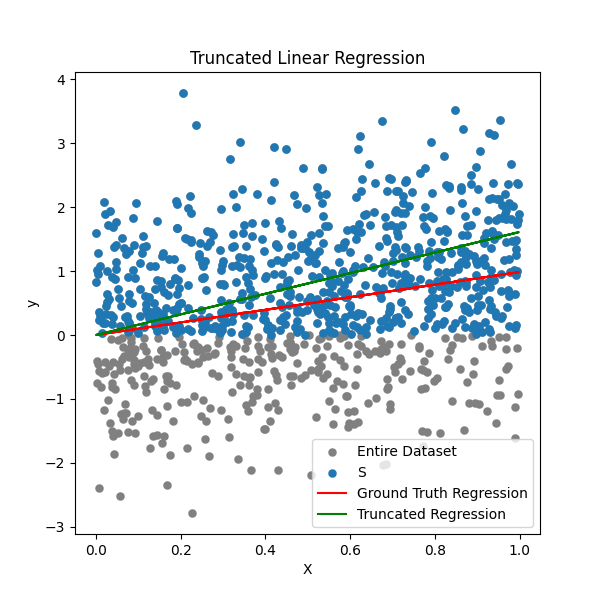

In [107]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.scatter(X, Y, linewidths=.1, color='grey', label='Entire Dataset')
ax.scatter(X_trunc, Y_trunc, linewidths=.1, label='S')
ax.plot(X.sort()[0], gt_lin_reg.predict(X.sort()[0]), color='red', label='Ground Truth Regression')
ax.plot(X.sort()[0], trunc_lin_reg.predict(X.sort()[0]), color='green', label='Truncated Regression')
ax.set_xlabel('X')
ax.set_ylabel('y')
ax.set_title('Truncated Linear Regression')
ax.legend()
plt.show()

<IPython.core.display.Javascript object>


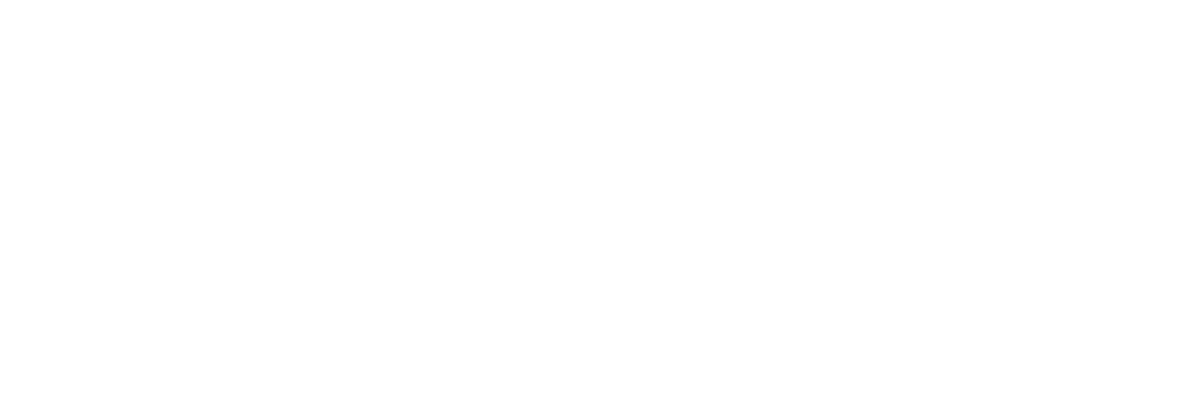

In [108]:
ws = ch.linspace(-1, 5, 20)

losses = ch.Tensor([])
grads = ch.Tensor([])

for w in ws: 
    loss, grad = trunc_mse(X_trunc @ w.reshape(1, 1), Y_trunc, phi, ch.ones(1))
    losses = ch.cat([losses, loss[...,None].detach()])
    grads = ch.cat([grads, (grad * X_trunc).sum(0)])
    
# === Plot the loss landscape ===
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(ws, losses)
ax1.set_xlabel("w value")
ax1.set_ylabel("Negative log-likelihood")
ax1.set_title("Truncated Linear Regression Conditional NLL vs w")

ax2.plot(ws, grads)
ax2.set_xlabel("w value")
ax2.set_ylabel("Gradient")
ax2.set_title("Gradient of Truncated Linear Regression Conditional NLL vs w")

plt.show()

# One Dimensional Linear Regression with Bias

In [102]:
W = ch.ones(1)
W0 = ch.ones(1)
print(f'groud truth W:\n {W}')
print(f'ground truth bias:\n {W0}')

X = ch.rand(1000, 1)
print(f'ground truth num samples: {X.size(0)}')

Y = X @ W + W0 + ch.randn(X.size(0))

gt_lin_reg = LinearRegression()
gt_lin_reg.fit(X, Y)

W_fit = gt_lin_reg.coef_
W0_fit = gt_lin_reg.intercept_

print(f'W fit:\n {W_fit}')
print(f'W0 fit:\n {W0_fit}')

groud truth W:
 tensor([1.])
ground truth bias:
 tensor([1.])
ground truth num samples: 1000
W fit:
 [1.0604794]
W0 fit:
 0.9840986728668213


In [103]:
def phi(X): 
    return X > 1

trunc_indices = phi(Y).nonzero()
alpha = trunc_indices.size(0) / X.size(0)
print(f'alpha:\n {alpha:.3f}')

Y_trunc = Y[trunc_indices]
X_trunc = X[trunc_indices.flatten()]

trunc_lin_reg = LinearRegression()
trunc_lin_reg.fit(X_trunc, Y_trunc)

print(f'trunc lin reg W:\n {trunc_lin_reg.coef_}')
print(f'trunc lin reg W0:\n {trunc_lin_reg.intercept_}')

alpha:
 0.698
trunc lin reg W:
 [[0.5224755]]
trunc lin reg W0:
 [1.75208]


<IPython.core.display.Javascript object>


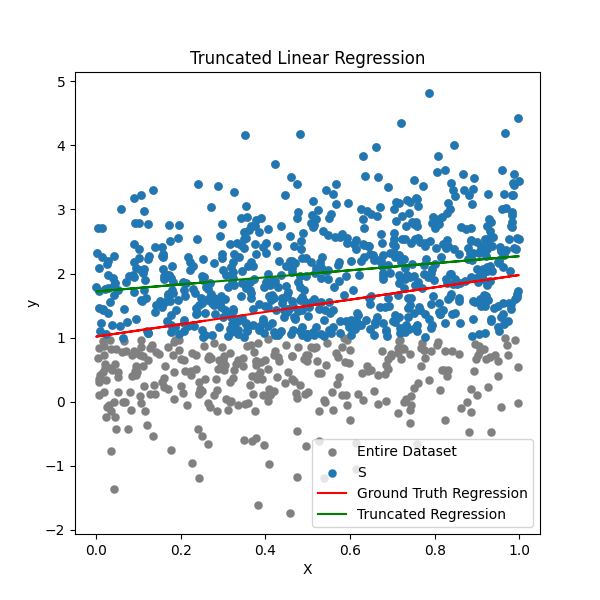

In [90]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.scatter(X, Y, linewidths=.1, color='grey', label='Entire Dataset')
ax.scatter(X_trunc, Y_trunc, linewidths=.1, label='S')
ax.plot(X.sort()[0], gt_lin_reg.predict(X.sort()[0]), color='red', label='Ground Truth Regression')
ax.plot(X.sort()[0], trunc_lin_reg.predict(X.sort()[0]), color='green', label='Truncated Regression')
ax.set_xlabel('X')
ax.set_ylabel('y')
ax.set_title('Truncated Linear Regression')
ax.legend()
plt.show()

In [98]:
# === Parameter grids ===
W_values = ch.linspace(0, 2, 25)
W0_values = ch.linspace(0, 2, 25)
W_, W0_ = ch.meshgrid(W_values, W0_values)

X_trunc_ones = ch.cat([X_trunc, ch.ones_like(X_trunc)], dim=1)

# === Compute NLL over the grid ===
Z = np.zeros_like(W_)
GRAD_W = ch.zeros_like(W_)
GRAD_W0 = ch.zeros_like(W0_)
for i in range(len(W_values)):
    for j in range(len(W0_values)):
        trunc_pred = X_trunc_ones @ ch.cat([W_[i, j][None,...], W0_[i, j][None,...]])[...,None]
        loss, grad = trunc_mse(trunc_pred, Y_trunc, phi, ch.ones(1))
    
        grad_ = (grad * X_trunc_ones).sum(0)

        Z[i, j] = loss
        GRAD_W[i, j] = grad_[0]
        GRAD_W0[i, j] = grad_[1]
    
# Find the minimum point 
min_idx = np.unravel_index(np.argmin(Z), Z.shape)
W_min, W0_min = W_[min_idx], W0_[min_idx]
min_loss = Z[min_idx]

print(f"Ground truth: w={W.item():.3f}, w0={W0.item():.3f}")
print(f"Minimum found: w={W_min:.3f}, w0={W0_min:.3f}, loss={min_loss:.3f}")
gt_loss = trunc_mse((X_trunc_ones @ ch.cat([W, W0]))[None,...], Y_trunc, phi, ch.ones(1))[0]
print(f"\nLoss at ground truth: {gt_loss:.3f}")
print(f"Loss at minimum: {min_loss:.3f}")
print(f"Difference: {gt_loss - min_loss:.3f}")

# === Plot the loss landscape ===
fig = plt.figure(figsize=(10, 10))

ax1 = fig.add_subplot(221)

cp = ax1.contourf(W_, W0_, Z, levels=30, cmap="viridis")
plt.colorbar(cp, ax=ax1, label="Negative log-likelihood")

ax1.set_title("Truncated Regression NLL Landscape")
ax1.set_xlabel("w value")
ax1.set_ylabel("w0 value")

# mark the ground truth
ax1.plot(W.item(), W0.item(), 'bo', markersize=10, label="Ground Truth")
ax1.plot(W_min.item(), W0_min.item(), 'r*', markersize=10, label="Minimum")
ax1.legend()

# Plot 4: Gradient
ax4 = fig.add_subplot(222)

# Plot quiver
Q = ax4.quiver(W_, W0_, GRAD_W, GRAD_W0,
               color='red', alpha=0.7, width=0.003, scale=50, headwidth=5)

# Add contour of loss for context
contour = ax4.contour(W_, W0_, Z, levels=15, colors='black', alpha=0.3, linewidths=0.5)
ax4.clabel(contour, inline=True, fontsize=8, fmt="%.1f")

# Mark minimum and ground truth
ax4.plot(W.item(), W0.item(), 'bo', markersize=10, markeredgecolor='white', label='Ground truth')
ax4.plot(W_min, W0_min, 'r*', markersize=15, markeredgecolor='white', label='Minimum')

ax4.set_xlabel('w')
ax4.set_ylabel('w0')
ax4.set_title('Gradient Vector Field\n(Arrows = ∇L, point uphill)')
ax4.legend()
ax4.grid(True, linestyle='--', alpha=0.5)

# Plot 1: 3D surface plot
ax3 = fig.add_subplot(223, projection='3d')
surf = ax3.plot_surface(W_, W0_, Z, cmap='viridis', alpha=0.8, 
                       linewidth=0, antialiased=True)
ax3.scatter([W_min], [W0_min], [min_loss], color='red', s=100, 
           label='Minimum', marker='*', edgecolors='white')
ax3.scatter([W.item()], [W0.item()], [np.min(Z)], 
           color='blue', s=100, label='Ground truth', marker='o', edgecolors='white')
ax3.set_xlabel('w')
ax3.set_ylabel('w0')
ax3.set_zlabel('Negative Log-Likelihood')
ax3.set_title('3D Loss Landscape')
ax3.legend()

plt.tight_layout()
plt.show()

RuntimeError: mat1 and mat2 shapes cannot be multiplied (308x4 and 2x1)

# Two Dimensional Truncated Linear Regression

In [93]:
W = ch.ones(2)
W0 = ch.ones(1)
print(f'groud truth W:\n {W}')

r1, r2 = -2, 2
X = (r1 - r2) * ch.rand(1000, 2) + r2
print(f'ground truth num samples: {X.size(0)}')

Y = X @ W + W0 + ch.randn(X.size(0))

gt_lin_reg = LinearRegression(fit_intercept=True)
gt_lin_reg.fit(X, Y)

W_fit = gt_lin_reg.coef_
W0_fit = gt_lin_reg.intercept_

print(f'W fit:\n {W_fit}')
print(f'W0 fit:\n {W0_fit}')

groud truth W:
 tensor([1., 1.])
ground truth num samples: 1000
W fit:
 [0.96928006 0.9646735 ]
W0 fit:
 1.022058367729187


In [94]:
def phi(X): 
    return X > 2

trunc_indices = phi(Y).nonzero()
alpha = trunc_indices.size(0) / X.size(0)
print(f'alpha:\n {alpha:.3f}')

Y_trunc = Y[trunc_indices]
X_trunc = X[trunc_indices.flatten()]

trunc_lin_reg = LinearRegression()
trunc_lin_reg.fit(X_trunc, Y_trunc)

print(f'trunc lin reg W:\n {trunc_lin_reg.coef_}')
print(f'trunc lin reg W0:\n {trunc_lin_reg.intercept_}')

alpha:
 0.308
trunc lin reg W:
 [[0.50896615 0.47191682]]
trunc lin reg W0:
 [2.3464224]


<IPython.core.display.Javascript object>


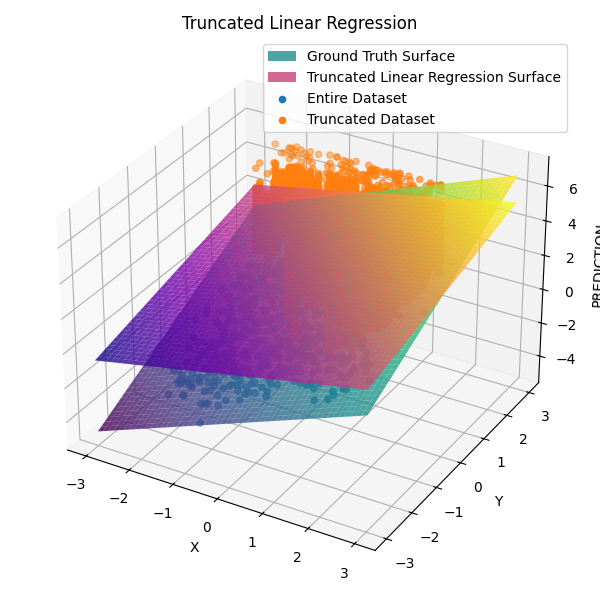

In [95]:
X_lin_space = ch.linspace(-3, 3, 50)
Y_lin_space = ch.linspace(-3, 3, 50)
X_, Y_ = meshgrid = ch.meshgrid(X_lin_space, Y_lin_space)

PRED = ch.zeros_like(X_)
TRUNC_PRED = ch.zeros_like(X_)
for i in range(len(X_)): 
    for j in range(len(Y_)): 
        x_ = ch.cat([X_[i, j][None,...], Y_[i, j][None,...]])[None,...]
        PRED[i, j] = ch.from_numpy(gt_lin_reg.predict(x_))
        TRUNC_PRED[i, j] = ch.from_numpy(trunc_lin_reg.predict(x_))
        
fig = plt.figure(figsize=(6, 6))

ax1 = fig.add_subplot(111, projection='3d')
surf = ax1.plot_surface(X_, Y_, PRED, cmap='viridis', alpha=0.8, 
                       linewidth=0, antialiased=True, label="Ground Truth Surface")
surf = ax1.plot_surface(X_, Y_, TRUNC_PRED, cmap='plasma', alpha=0.8, 
                       linewidth=0, antialiased=True, label="Truncated Linear Regression Surface")
ax1.scatter(X[:,0], X[:,1], Y, label="Entire Dataset")
ax1.scatter(X_trunc[:,0], X_trunc[:,1], Y_trunc, label="Truncated Dataset")

ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('PREDICTION')
ax1.set_title('Truncated Linear Regression')
ax1.legend()

plt.tight_layout()
plt.show()

Ground truth: w1=1.000, w2=1.000
Minimum found: w1=1.000, w2=0.917, loss=0.843

Loss at ground truth: 0.847
Loss at minimum: 0.843
Difference: 0.004


<IPython.core.display.Javascript object>


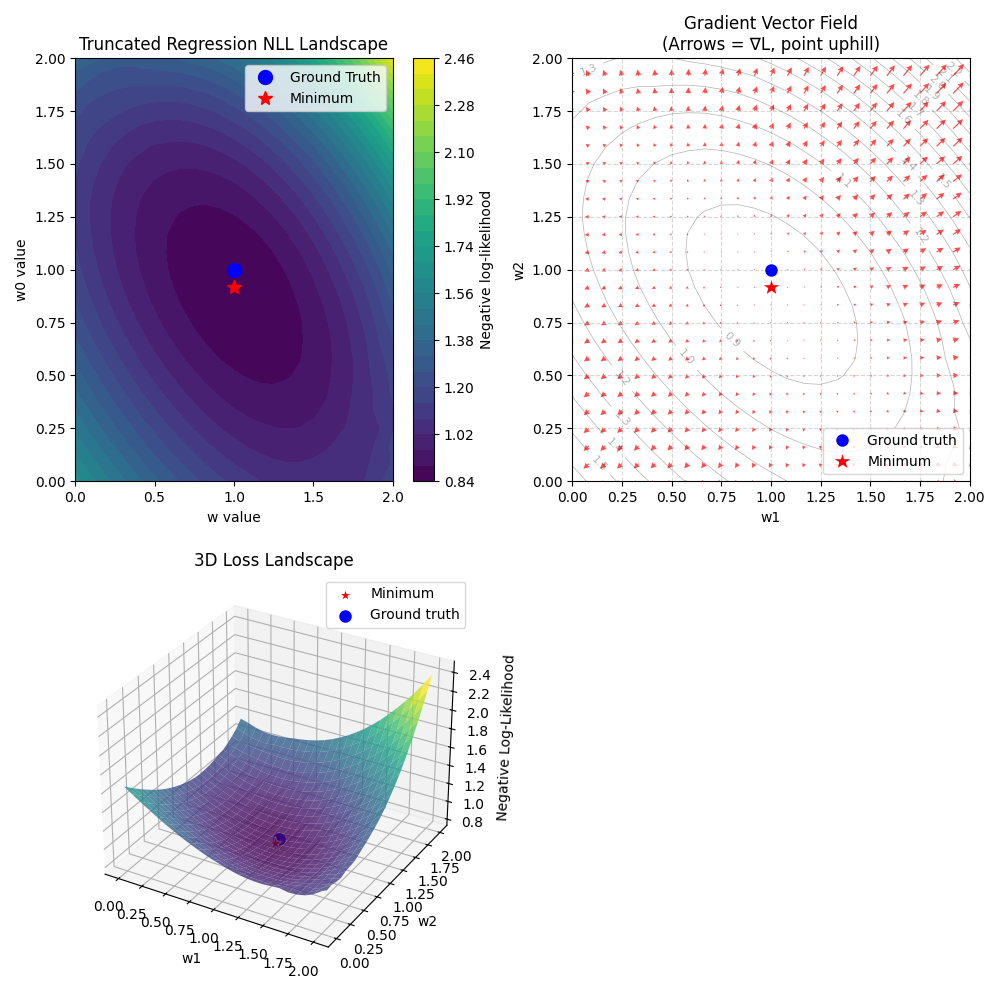

In [97]:
# === Parameter grids ===
W1_values = ch.linspace(0, 2, 25)
W2_values = ch.linspace(0, 2, 25)
W1_, W2_ = ch.meshgrid(W1_values, W2_values)

X_trunc_ones = ch.cat([X_trunc, ch.ones_like(X_trunc[:,0][...,None])], dim=1)

# === Compute NLL over the grid ===
Z = np.zeros_like(W1_)
GRAD_W1 = ch.zeros_like(W1_)
GRAD_W2 = ch.zeros_like(W2_)
for i in range(len(W1_values)):
    for j in range(len(W2_values)):
        trunc_pred = X_trunc_ones @ ch.cat([W1_[i, j][None,...], W2_[i, j][None,...], ch.ones(1)])[...,None]
        loss, grad = trunc_mse(trunc_pred, Y_trunc, phi, ch.ones(1))
        grad_ = (grad * X_trunc_ones).sum(0)

        Z[i, j] = loss
        GRAD_W1[i, j] = grad_[0]
        GRAD_W2[i, j] = grad_[1]
    
# Find the minimum point 
min_idx = np.unravel_index(np.argmin(Z), Z.shape)
W1_min, W2_min = W1_[min_idx], W2_[min_idx]
min_loss = Z[min_idx]

print(f"Ground truth: w1={W[0].item():.3f}, w2={W[1].item():.3f}")
print(f"Minimum found: w1={W1_min:.3f}, w2={W2_min:.3f}, loss={min_loss:.3f}")
gt_loss = trunc_mse((X_trunc_ones @ ch.cat([W, W0]))[...,None], Y_trunc, phi, ch.ones(1))[0]
print(f"\nLoss at ground truth: {gt_loss:.3f}")
print(f"Loss at minimum: {min_loss:.3f}")
print(f"Difference: {gt_loss - min_loss:.3f}")

# === Plot the loss landscape ===
fig = plt.figure(figsize=(10, 10))

ax1 = fig.add_subplot(221)

cp = ax1.contourf(W1_, W2_, Z, levels=30, cmap="viridis")
plt.colorbar(cp, ax=ax1, label="Negative log-likelihood")

ax1.set_title("Truncated Regression NLL Landscape")
ax1.set_xlabel("w value")
ax1.set_ylabel("w0 value")

# mark the ground truth
ax1.plot(W[0].item(), W[1].item(), 'bo', markersize=10, label="Ground Truth")
ax1.plot(W1_min.item(), W2_min.item(), 'r*', markersize=10, label="Minimum")
ax1.legend()

# Plot 4: Gradient
ax4 = fig.add_subplot(222)

# Plot quiver
Q = ax4.quiver(W1_, W2_, GRAD_W1, GRAD_W2,
               color='red', alpha=0.7, width=0.003, scale=50, headwidth=5)

# Add contour of loss for context
contour = ax4.contour(W1_, W2_, Z, levels=15, colors='black', alpha=0.3, linewidths=0.5)
ax4.clabel(contour, inline=True, fontsize=8, fmt="%.1f")

# Mark minimum and ground truth
ax4.plot(W[0].item(), W[1].item(), 'bo', markersize=10, markeredgecolor='white', label='Ground truth')
ax4.plot(W1_min, W2_min, 'r*', markersize=15, markeredgecolor='white', label='Minimum')

ax4.set_xlabel('w1')
ax4.set_ylabel('w2')
ax4.set_title('Gradient Vector Field\n(Arrows = ∇L, point uphill)')
ax4.legend()
ax4.grid(True, linestyle='--', alpha=0.5)

# Plot 1: 3D surface plot
ax3 = fig.add_subplot(223, projection='3d')
surf = ax3.plot_surface(W1_, W2_, Z, cmap='viridis', alpha=0.8, 
                       linewidth=0, antialiased=True)
ax3.scatter([W1_min], [W2_min], [min_loss], color='red', s=100, 
           label='Minimum', marker='*', edgecolors='white')
ax3.scatter([W[0].item()], [W[1].sqrt().item()], [np.min(Z)], 
           color='blue', s=100, label='Ground truth', marker='o', edgecolors='white')
ax3.set_xlabel('w1')
ax3.set_ylabel('w2')
ax3.set_zlabel('Negative Log-Likelihood')
ax3.set_title('3D Loss Landscape')
ax3.legend()

plt.tight_layout()
plt.show()

# Run Procedure - 1 Dimension No Intercept

In [37]:
W = ch.ones(1)
NOISE_VAR = 1.0
print(f'groud truth W:\n {W}')

X = ch.rand(5000, 1)
print(f'ground truth num samples: {X.size(0)}')

Y = X @ W + NOISE_VAR**.5 * ch.randn(X.size(0))

gt_lin_reg = LinearRegression(fit_intercept=False)
gt_lin_reg.fit(X, Y)

W_fit = gt_lin_reg.coef_

print(f'W fit:\n {W_fit}')

groud truth W:
 tensor([1.])
ground truth num samples: 5000
W fit:
 [1.0430729]


In [38]:
def phi(X): 
    return X > 0

trunc_indices = phi(Y).nonzero()
alpha = trunc_indices.size(0) / X.size(0)
print(f'alpha:\n {alpha:.3f}')

Y_trunc = Y[trunc_indices]
X_trunc = X[trunc_indices.flatten()]

trunc_lin_reg = LinearRegression(fit_intercept=False)
trunc_lin_reg.fit(X_trunc, Y_trunc)

print(f'trunc lin reg W:\n {trunc_lin_reg.coef_}')

alpha:
 0.689
trunc lin reg W:
 [[1.6465193]]


In [39]:
from torch.nn import MSELoss
mse_loss = MSELoss()

gt_norm = LinearRegression(fit_intercept=False)
gt_norm.fit(X, Y)
gt_ = ch.from_numpy(gt_norm.coef_.flatten())

# calculate empirical noise variance for regression 
ols_trunc = LinearRegression(fit_intercept=False)
ols_trunc.fit(X_trunc, Y_trunc)
emp_ = ch.from_numpy(ols_trunc.coef_.flatten())
print(f'empirical weights: {emp_}')
emp_mse_loss = mse_loss(emp_, gt_)
print(f'emp mse loss: {emp_mse_loss}')

empirical weights: tensor([1.6465])
emp mse loss: 0.36414751410484314


In [40]:
from delphi.stats import TruncatedLinearRegression 
from delphi import oracle
from delphi.utils.helpers import Parameters

y_trunc_scale = Y_trunc / (NOISE_VAR ** .5)
# train algorithm
args = Parameters({'epochs': 10,
                    'lr': 1e-1,
                    'batch_size': 100,
                    'trials': 1,
                    'verbose': True
                        }) 
trunc_reg = TruncatedLinearRegression(args, 
                                      phi,
                                      alpha,
                                      noise_var=ch.ones(1, 1), 
                                        fit_intercept=False)
trunc_reg.fit(X_trunc, y_trunc_scale)

trial: 1
Creating SGD optimizer: {'lr': 0.1, 'momentum': 0.0, 'dampening': 0.0, 'weight_decay': 0.0, 'nesterov': False, 'maximize': False, 'differentiable': False}
Epoch 1 - Loss: 0.9416490793228149
Epoch 2 - Loss: 0.9315452575683594
Epoch 3 - Loss: 0.9274343252182007
Epoch 4 - Loss: 0.9262601137161255
Epoch 5 - Loss: 0.9259127378463745
Epoch 6 - Loss: 0.925902783870697
Epoch 7 - Loss: 0.9251096844673157
Epoch 8 - Loss: 0.9253483414649963
Epoch 9 - Loss: 0.9252715110778809
Epoch 10 - Loss: 0.9253265857696533


TruncatedLinearRegression()

In [41]:
ws = ch.linspace(-1, 2, 20)

losses = [trunc_mse(X_trunc*w, Y_trunc, phi, ch.ones(1))[0].sum().detach() for w in ws]

<IPython.core.display.Javascript object>


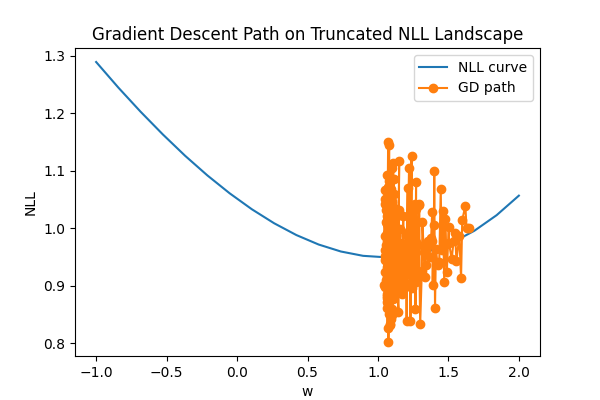

In [42]:
param_history = trunc_reg.trainer.param_history.detach()
loss_history = trunc_reg.trainer.loss_history.detach()

plt.figure(figsize=(6,4))
plt.plot(ws, losses, label="NLL curve")
plt.plot(param_history, loss_history, marker="o", label="GD path")
plt.xlabel("w")
plt.ylabel("NLL")
plt.title("Gradient Descent Path on Truncated NLL Landscape")
plt.legend()
plt.show()

# Run Procedure - One Dimension with Intercept

In [44]:
W = ch.ones(1)
W0 = ch.ones(1)
NOISE_VAR = 1.0
print(f'groud truth W:\n {W}')

X = ch.rand(5000, 1)
print(f'ground truth num samples: {X.size(0)}')

Y = X @ W + W0 + NOISE_VAR**.5 * ch.randn(X.size(0))

gt_lin_reg = LinearRegression(fit_intercept=False)
gt_lin_reg.fit(X, Y)

W_fit = gt_lin_reg.coef_

print(f'W fit:\n {W_fit}')

groud truth W:
 tensor([1.])
ground truth num samples: 5000
W fit:
 [2.5349514]


In [57]:
def phi(X): 
    return X > 1

trunc_indices = phi(Y).nonzero()
alpha = trunc_indices.size(0) / X.size(0)
print(f'alpha:\n {alpha:.3f}')

Y_trunc = Y[trunc_indices]
X_trunc = X[trunc_indices.flatten()]

trunc_lin_reg = LinearRegression()
trunc_lin_reg.fit(X_trunc, Y_trunc)

print(f'trunc lin reg W:\n {trunc_lin_reg.coef_}')
print(f'trunc lin reg W0:\n {trunc_lin_reg.intercept_}')

alpha:
 0.687
trunc lin reg W:
 [[0.5196967]]
trunc lin reg W0:
 [1.7745258]


In [55]:
from torch.nn import MSELoss
mse_loss = MSELoss()

gt_norm = LinearRegression()
gt_norm.fit(X, Y)
gt_ = ch.from_numpy(np.concatenate([gt_norm.coef_.flatten(), gt_norm.intercept_.reshape(1,)]))

# calculate empirical noise variance for regression 
ols_trunc = LinearRegression()
ols_trunc.fit(X_trunc, Y_trunc)
emp_ = ch.from_numpy(np.concatenate([ols_trunc.coef_.flatten(), ols_trunc.intercept_.reshape(1,)]))
print(f'empirical weights: {emp_}')
emp_mse_loss = mse_loss(emp_, gt_)
print(f'emp mse loss: {emp_mse_loss}')

empirical weights: tensor([0.5197, 1.7745])
emp mse loss: 0.41981032490730286


In [58]:
from delphi.stats import TruncatedLinearRegression 
from delphi import oracle
from delphi.utils.helpers import Parameters

y_trunc_scale = Y_trunc / (NOISE_VAR ** .5)
# train algorithm
args = Parameters({'epochs': 10,
                    'lr': 1e-1,
                    'batch_size': 100,
                    'trials': 1,
                    'verbose': True
}) 
trunc_reg = TruncatedLinearRegression(args, 
                                      phi,
                                      alpha,
                                      noise_var=ch.ones(1, 1))
trunc_reg.fit(X_trunc, y_trunc_scale)

trial: 1
Creating SGD optimizer: {'lr': 0.1, 'momentum': 0.0, 'dampening': 0.0, 'weight_decay': 0.0, 'nesterov': False, 'maximize': False, 'differentiable': False}
Epoch 1 - Loss: 0.938123345375061
Epoch 2 - Loss: 0.9347988367080688
Epoch 3 - Loss: 0.9334178566932678
Epoch 4 - Loss: 0.9325458407402039
Epoch 5 - Loss: 0.9311288595199585
Epoch 6 - Loss: 0.9312825798988342
Epoch 7 - Loss: 0.9297131896018982
Epoch 8 - Loss: 0.9289311170578003
Epoch 9 - Loss: 0.9288210868835449
Epoch 10 - Loss: 0.9281923770904541


TruncatedLinearRegression()

/tmp/ipykernel_44133/2525267241.py:23: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  min_idx = np.unravel_index(np.argmin(Z), Z.shape)


Ground truth: w=1.000, w0=1.000
Minimum found: w=1.556, w0=0.667, loss=0.940

Loss at ground truth: 0.977
Loss at minimum: 0.940
Difference: 0.036


<IPython.core.display.Javascript object>


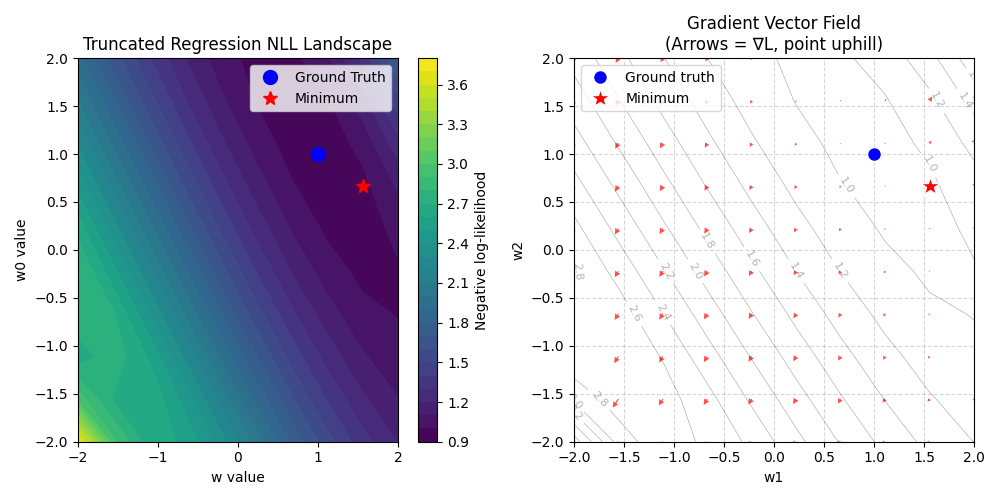

In [82]:
param_history = trunc_reg.trainer.param_history.detach()
loss_history = trunc_reg.trainer.loss_history.detach()

X_trunc_ones = ch.cat([X_trunc, ch.ones(X_trunc.size(0), 1)], dim=1)

W_ = ch.linspace(-2, 2, 10)
W0_ = ch.linspace(-2, 2, 10)
W_mesh, W0_mesh = ch.meshgrid(W_, W0_)

Z = ch.zeros_like(W_mesh)
GRAD_W = ch.zeros_like(W_mesh)
GRAD_W0 = ch.zeros_like(W_mesh)
for i in range(len(W_)): 
    for j in range(len(W0_)):
        
        loss, grad = trunc_mse(X_trunc*W_mesh[i, j] + W0_mesh[i, j], Y_trunc, phi, ch.ones(1))
        grad_ = (grad * X_trunc_ones).sum(0)
        Z[i, j] = loss.sum().detach()
        GRAD_W[i, j] = grad_[0]
        GRAD_W0[i, j] = grad_[1]
        
# Find the minimum point 
min_idx = np.unravel_index(np.argmin(Z), Z.shape)
W_min, W0_min = W_mesh[min_idx], W0_mesh[min_idx]
min_loss = Z[min_idx]

print(f"Ground truth: w={W.item():.3f}, w0={W0.item():.3f}")
print(f"Minimum found: w={W_min:.3f}, w0={W0_min:.3f}, loss={min_loss:.3f}")
gt_loss = trunc_mse((X_trunc_ones @ ch.cat([W, W0]))[None,...], Y_trunc, phi, ch.ones(1))[0]
print(f"\nLoss at ground truth: {gt_loss:.3f}")
print(f"Loss at minimum: {min_loss:.3f}")
print(f"Difference: {gt_loss - min_loss:.3f}")
        
# === Plot the loss landscape ===
fig = plt.figure(figsize=(10, 5))

ax1 = fig.add_subplot(121)

cp = ax1.contourf(W_, W0_, Z, levels=30, cmap="viridis")
plt.colorbar(cp, ax=ax1, label="Negative log-likelihood")

ax1.set_title("Truncated Regression NLL Landscape")
ax1.set_xlabel("w value")
ax1.set_ylabel("w0 value")

# mark the ground truth
ax1.plot(W.item(), W0.item(), 'bo', markersize=10, label="Ground Truth")
ax1.plot(W_min.item(), W0_min.item(), 'r*', markersize=10, label="Minimum")
ax1.legend()

# Plot 4: Gradient
ax4 = fig.add_subplot(122)

# Plot quiver
Q = ax4.quiver(W_, W0_, GRAD_W, GRAD_W0,
               color='red', alpha=0.7, width=0.003, scale=50, headwidth=5)

# Add contour of loss for context
contour = ax4.contour(W_, W0_, Z, levels=15, colors='black', alpha=0.3, linewidths=0.5)
ax4.clabel(contour, inline=True, fontsize=8, fmt="%.1f")

# Mark minimum and ground truth
ax4.plot(W.item(), W0.item(), 'bo', markersize=10, markeredgecolor='white', label='Ground truth')
ax4.plot(W_min, W0_min, 'r*', markersize=15, markeredgecolor='white', label='Minimum')

ax4.set_xlabel('w1')
ax4.set_ylabel('w2')
ax4.set_title('Gradient Vector Field\n(Arrows = ∇L, point uphill)')
ax4.legend()
ax4.grid(True, linestyle='--', alpha=0.5)
       
    
plt.tight_layout()
plt.show()

In [69]:
W_mesh[min_idx]

tensor(0.5263)

In [76]:
X_trunc*W_mesh[i, j] + W0_mesh[i, j]

tensor([[1.4809],
        [1.3059],
        [1.1854],
        ...,
        [0.9017],
        [1.4063],
        [1.2838]])